# Q1

In [1]:
import idx2numpy
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [2]:
# load the raw MNIST files
images = idx2numpy.convert_from_file('MNIST/train-images.idx3-ubyte')
labels = idx2numpy.convert_from_file('MNIST/train-labels.idx1-ubyte')

In [3]:
# subset to digits 0–4
mask = np.isin(labels, [0,1,2,3,4])
imgs_sub = images[mask]
y_sub    = labels[mask]

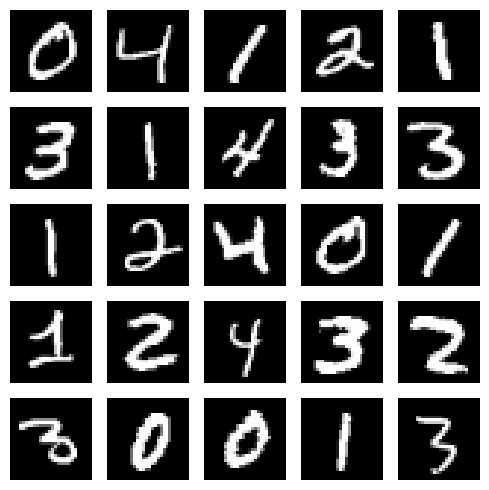

In [4]:
# visualize the first 25 raw 28×28 images
fig, axes = plt.subplots(5,5, figsize=(5,5))
for i, ax in enumerate(axes.flat):
    ax.imshow(imgs_sub[i], cmap='gray', interpolation='nearest')
    ax.axis('off')
plt.tight_layout()
plt.show()

In [5]:
# Cdefine a 2×2 to 1×1 compression (28×28 → 14×14)
def compress14(img28):
    """
    img28: a (28×28) numpy array
    returns: a flattened length-196 (14×14) float array
    """
    small = np.empty((14,14), dtype=np.float32)
    for i in range(14):
        for j in range(14):
            block = img28[2*i:2*i+2, 2*j:2*j+2]
            small[i,j] = block.mean()
    return small.flatten()

In [6]:
# apply compression to entire subset
X_comp = np.vstack([compress14(img) for img in imgs_sub])

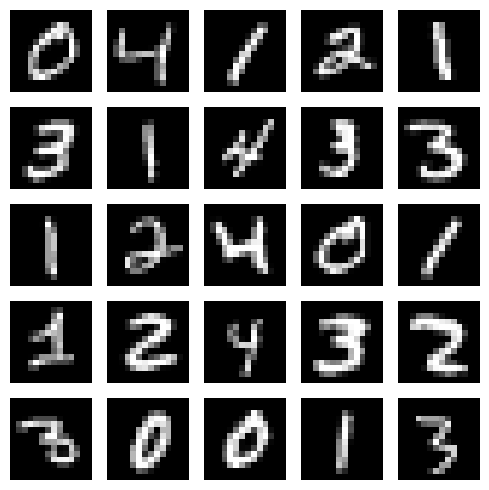

In [7]:
# visualize the first 25 compressed 14×14 images
fig, axes = plt.subplots(5,5, figsize=(5,5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_comp[i].reshape(14,14), cmap='gray', interpolation='nearest')
    ax.axis('off')
plt.tight_layout()
plt.show()

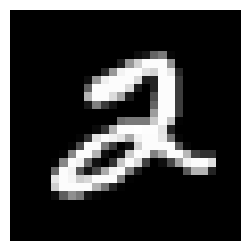

In [8]:
# display a single raw 28×28 MNIST digit
idx = 3  
plt.figure(figsize=(3,3))
plt.imshow(imgs_sub[idx], cmap='gray', interpolation='nearest')
plt.axis('off')
plt.show()

# Q3

In [9]:
# define logsunmexp helper function
def logsumexp(a, axis=1):
    """
    Compute log(sum(exp(a), axis=axis)) in a numerically stable way.

    a: a 2D numpy array
    axis: axis along which to sum
    returns: a 1D numpy array of length a.shape[0] (number of rows)
    """
    a_max = np.max(a, axis=axis, keepdims=True)
    return (a_max + np.log(np.sum(np.exp(a - a_max), axis=axis, keepdims=True))).squeeze()

# define softmax helper function
def softmax(a):
    """
    Row‐wise softmax of a 2D array a.
    
    a: a 2D numpy array 
    returns: a 2D numpy array of the same shape as a, with softmax applied
    """
    a_max = np.max(a, axis=1, keepdims=True)
    exp_a = np.exp(a - a_max)
    return exp_a / exp_a.sum(axis=1, keepdims=True)

In [10]:
# initialization of GMM parameters
def initialize_params(X, y, size=0.35, n_clusters=5, method='spherical', seed=243):
    """
    Initialize GMM parameters for the EM algorithm.
    
    X: a 2D numpy array of shape (n_samples, n_features)
    y: a 1D numpy array of shape (n_samples,) with integer labels
    size: fraction of data to use for initialization
    n_clusters: number of clusters
    method: 'spherical' or 'diagonal' covariance matrix
    seed: random seed for reproducibility
    returns: a dictionary with keys 'mu', 'sigma', and 'pi'
    """
    # set random seed for reproducibility
    if seed is not None:
        np.random.seed(seed)
    else:
        seed = np.random.randint(0, 10000)
    # subset the data
    np.random.seed(seed)
    n, d = X.shape
    idx = np.random.choice(n, size=int(n * size), replace=False)
    X_sub, y_sub = X[idx], y[idx]

    # cluster means
    mu = np.zeros((n_clusters, d))
    for j in range(n_clusters):
        pts = X_sub[y_sub == j]
        mu[j] = pts.mean(axis=0) if len(pts) else X_sub.mean(axis=0)

    # variances
    if method == 'spherical':
        sigma = np.ones(n_clusters)      # sigma_j^2 = 1
    else:
        sigma = np.ones((n_clusters, d)) # diagonal sigma_j^2 = 1

    # mixing weights
    pi = np.ones(n_clusters) / n_clusters

    return {'mu': mu, 'sigma': sigma, 'pi': pi}

In [11]:
# Cell 3 — E‐step (log‐densities, responsibilities) & log‐likelihood
def cond_prob(X, params, method='spherical'):
    """
    Compute the conditional probabilities and log‐marginals.

    X: a 2D numpy array of shape (n_samples, n_features)
    params: a dictionary with keys 'mu', 'sigma', and 'pi'
    method: 'spherical' or 'diagonal' covariance matrix
    returns: a tuple (a, resp, log_margins)
    """
    n, d = X.shape
    k = params['mu'].shape[0]
    mu, sigma, pi = params['mu'], params['sigma'], params['pi']

    a = np.zeros((n, k))
    for j in range(k):
        diff = X - mu[j]
        if method == 'spherical':
            a[:, j] = (
                -0.5 * d * np.log(sigma[j])
                -0.5 * np.sum(diff**2, axis=1) / sigma[j]
                + np.log(pi[j])
            )
        else:
            a[:, j] = (
                -0.5 * np.sum(np.log(sigma[j]))
                -0.5 * np.sum(diff**2 / sigma[j], axis=1)
                + np.log(pi[j])
            )

    resp = softmax(a)
    log_margins = logsumexp(a, axis=1)
    return a, resp, log_margins

In [12]:
def log_likelihood(X, params, method):
    """
    Overall log‐likelihood = sum_i log_margins[i].
    
    X: a 2D numpy array of shape (n_samples, n_features)
    params: a dictionary with keys 'mu', 'sigma', and 'pi'
    method: 'spherical' or 'diagonal' covariance matrix
    returns: a float representing the log‐likelihood
    """
    _, _, logm = cond_prob(X, params, method)
    return np.sum(logm)

In [13]:
# the EM loop
def EM(X, y, size=0.5, epsilon=1e-4, method='spherical',
       seed=243, n_clusters=5):
    """
    EM algorithm for Gaussian Mixture Model (GMM) clustering.

    X: a 2D numpy array of shape (n_samples, n_features)
    y: a 1D numpy array of shape (n_samples,) with integer labels
    size: fraction of data to use for initialization
    epsilon: convergence threshold
    method: 'spherical' or 'diagonal' covariance matrix
    seed: random seed for reproducibility
    n_clusters: number of clusters
    returns: a tuple (params, history, resp)
    """
    params = initialize_params(X, y, size, n_clusters, method, seed)
    n, d = X.shape
    ll_old = log_likelihood(X, params, method)
    history = [ll_old]

    while True:
        # E-step
        _, resp, _ = cond_prob(X, params, method)
        Nk = resp.sum(axis=0)

        # M-step: update π, μ
        pi_new = Nk / n
        mu_new = (resp.T @ X) / Nk[:, None]

        # update σ
        if method == 'spherical':
            sigma_new = np.zeros(n_clusters)
            for j in range(n_clusters):
                diff = X - mu_new[j]
                sigma_new[j] = (resp[:, j] * np.sum(diff**2, axis=1)).sum() / (d * Nk[j])
        else:
            sigma_new = np.zeros((n_clusters, d))
            for j in range(n_clusters):
                diff2 = (X - mu_new[j])**2
                sigma_new[j] = (resp[:, j][:, None] * diff2).sum(axis=0) / Nk[j] + 0.05

        params = {'mu': mu_new, 'sigma': sigma_new, 'pi': pi_new}

        # check convergence
        ll_new = log_likelihood(X, params, method)
        history.append(ll_new)
        if abs((ll_new - ll_old) / ll_old) < epsilon:
            break
        ll_old = ll_new

    return params, history, resp

In [14]:
# define a function to calculate the error rate
def error_rate(cluster_ids, y_true):
    """
    Compute the error rate of clustering.
    
    cluster_ids: a 1D numpy array of cluster assignments
    y_true: a 1D numpy array of true labels
    returns: a float representing the error rate
    """
    # compute the error rate
    y_pred = np.zeros_like(y_true)
    for j in np.unique(cluster_ids):
        mask = (cluster_ids == j)
        vals, cnts = np.unique(y_true[mask], return_counts=True)
        if len(vals):
            y_pred[mask] = vals[np.argmax(cnts)]
    return np.mean(y_pred != y_true)


=== Method: spherical ===
Marginal Probability: [0.17835665 0.19714995 0.22185907 0.20198719 0.20064714]
Log-likelihood: -26315958.8176
Seed 243, error rate = 0.1237


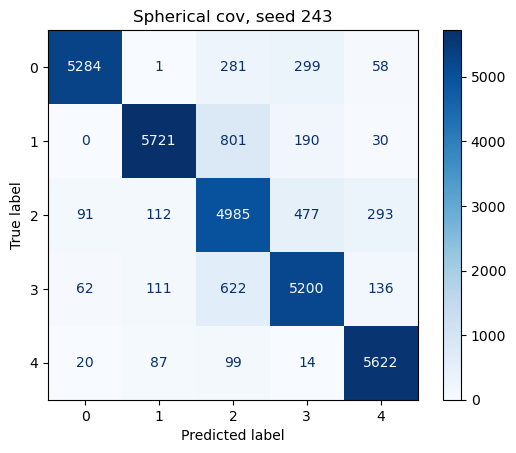

Marginal Probability: [0.17835665 0.19682311 0.22212054 0.20201987 0.20067983]
Log-likelihood: -26315942.1357
Seed 2025, error rate = 0.1238


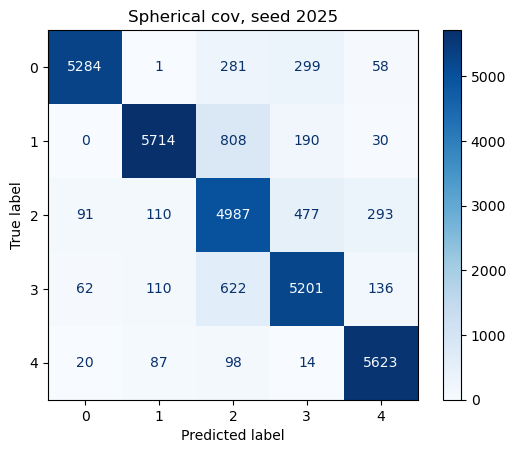

Marginal Probability: [0.17835665 0.19708459 0.22277422 0.20107204 0.20071251]
Log-likelihood: -26315951.6691
Seed 2432025, error rate = 0.1236


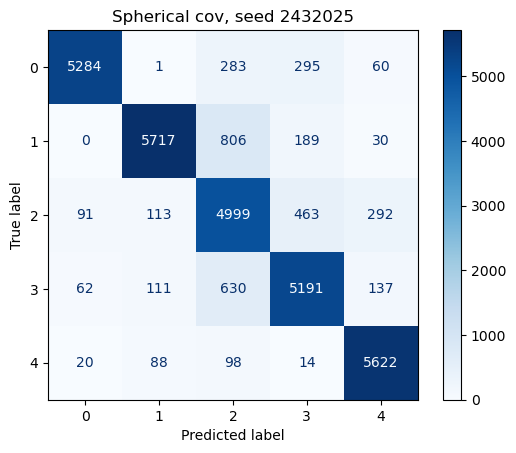


=== Method: diagonal ===
Marginal Probability: [0.32164335 0.25261472 0.12658517 0.21574716 0.0834096 ]
Log-likelihood: -10970248.1101
Seed 243, error rate = 0.4253


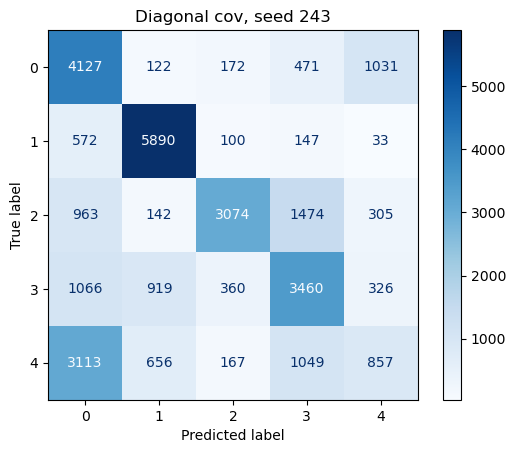

Marginal Probability: [0.3215453  0.24830043 0.12570271 0.2201595  0.08429206]
Log-likelihood: -10981888.9649
Seed 2025, error rate = 0.4265


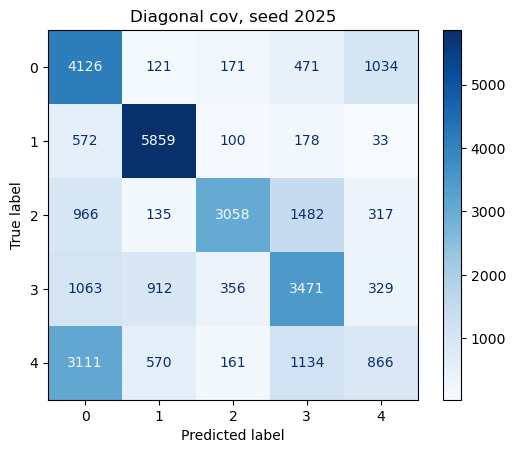

Marginal Probability: [0.3215453  0.24830043 0.12570271 0.2201595  0.08429206]
Log-likelihood: -10981889.0704
Seed 2432025, error rate = 0.4265


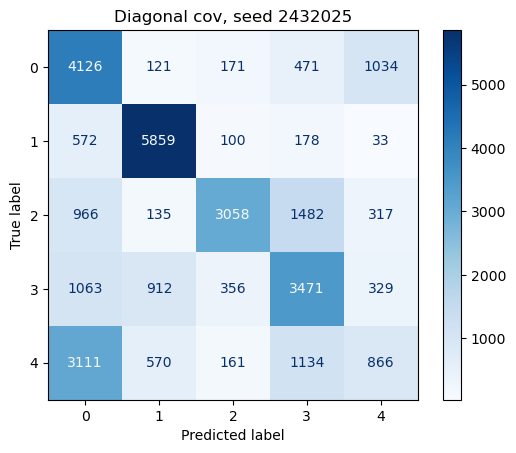

In [15]:
seeds = [243, 2025, 2432025]
for method in ['spherical', 'diagonal']:
    print(f"\n=== Method: {method} ===")
    for s in seeds:
        params, history, resp = EM(X_comp, y_sub,
                                   size=0.02,
                                   epsilon=1e-5,
                                   method=method,
                                   seed=s,
                                   n_clusters=5)
        preds = resp.argmax(axis=1)
        cm = confusion_matrix(y_sub, preds, labels=[0,1,2,3,4])
        _, counts = np.unique(preds, return_counts=True)
        print(f"Marginal Probability: {counts/counts.sum()}")
        print(f"Log-likelihood: {history[-1]:.4f}")
        print(f"Seed {s}, error rate = {error_rate(preds, y_sub):.4f}")
        disp = ConfusionMatrixDisplay(cm, display_labels=[0,1,2,3,4])
        disp.plot(cmap='Blues')
        plt.title(f"{method.capitalize()} cov, seed {s}")
        plt.show()